Name : Vishesh Kumar 
CU24250050   sec: B  Roll No: 69
Experiment - 1

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
print("Statistical Description:")
df.describe()

Statistical Description:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(891, 12)


In [10]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [11]:
print("Missing Value Percentage:")
print((df.isnull().sum() / len(df)) * 100)

Missing Value Percentage:
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [12]:
# Fill Age missing values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Embarked missing values with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Remove Cabin column because it has many missing values
df.drop("Cabin", axis=1, inplace=True)

print("Missing values handled successfully!")

print("\nRemaining Missing Values:")
print(df.isnull().sum())

Missing values handled successfully!

Remaining Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [13]:
# Check duplicate records
print("Duplicate records before removal:")
print(df.duplicated().sum())

# Remove duplicate records
df.drop_duplicates(inplace=True)

# Check duplicates again
print("\nDuplicate records after removal:")
print(df.duplicated().sum())

Duplicate records before removal:
0

Duplicate records after removal:
0


In [14]:
# Standardize Sex values
df["Sex"] = df["Sex"].str.lower()

# Standardize Embarked values
df["Embarked"] = df["Embarked"].str.upper()

print("Sex values:")
print(df["Sex"].unique())

print("\nEmbarked values:")
print(df["Embarked"].unique())

Sex values:
<StringArray>
['male', 'female']
Length: 2, dtype: str

Embarked values:
<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str


In [15]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding for Sex
label_encoder = LabelEncoder()

df["Sex_Encoded"] = label_encoder.fit_transform(df["Sex"])

print("After Label Encoding:")
print(df[["Sex", "Sex_Encoded"]].head())

After Label Encoding:
      Sex  Sex_Encoded
0    male            1
1  female            0
2  female            0
3  female            0
4    male            1


In [16]:
# One-Hot Encoding for Embarked
df = pd.get_dummies(
    df,
    columns=["Embarked"],
    drop_first=True,
    dtype=int
)

print("\nAfter One-Hot Encoding:")
print(df.head())


After One-Hot Encoding:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare  Sex_Encoded  Embarked_Q  Embarked_S  
0      0         A/5 21171   7.2500            1           0           1  
1      0          PC 17599  71.2833            0           0           0  
2      0  STON/O2. 3101282   7.9250            0           0          

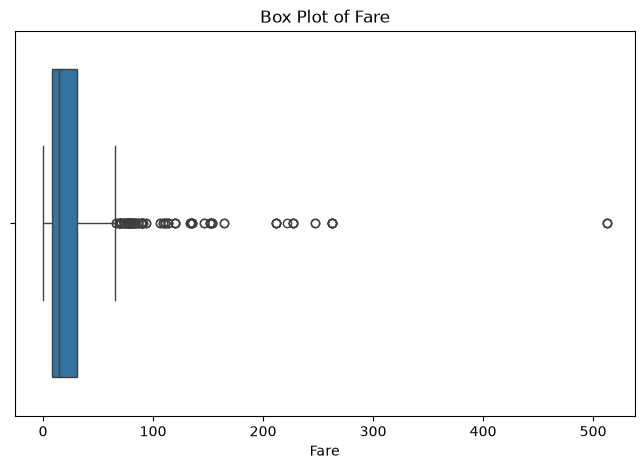

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Fare"])

plt.title("Box Plot of Fare")
plt.xlabel("Fare")

plt.show()

In [18]:
# Q1 and Q3
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower Limit: -26.724
Upper Limit: 65.6344


In [19]:
# Identify outliers
outliers = df[
    (df["Fare"] < lower_limit) |
    (df["Fare"] > upper_limit)
]

print("Number of Outliers:", len(outliers))

print("\nOutliers:")
print(outliers[["Fare"]].head(20))

Number of Outliers: 116

Outliers:
         Fare
1     71.2833
27   263.0000
31   146.5208
34    82.1708
52    76.7292
61    80.0000
62    83.4750
72    73.5000
88   263.0000
102   77.2875
118  247.5208
120   73.5000
124   77.2875
139   79.2000
151   66.6000
159   69.5500
180   69.5500
195  146.5208
201   69.5500
215  113.2750


In [20]:
# Treat outliers using capping
df["Fare"] = np.clip(
    df["Fare"],
    lower_limit,
    upper_limit
)

print("Outliers treated successfully!")

Outliers treated successfully!


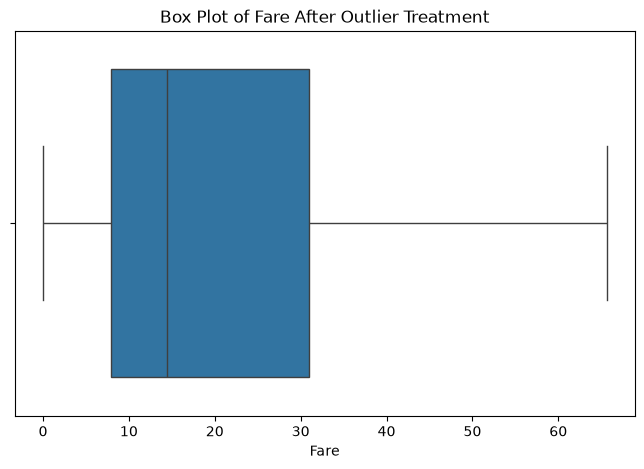

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Fare"])

plt.title("Box Plot of Fare After Outlier Treatment")
plt.xlabel("Fare")

plt.show()

In [22]:
# Create Family Size
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

print("Family Size created successfully!")

print(df[["SibSp", "Parch", "FamilySize"]].head())

Family Size created successfully!
   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1


In [23]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare  Sex_Encoded  Embarked_Q  Embarked_S  \
0      0         A/5 21171   7.2500            1           0           1   
1      0          PC 17599  65.6344            0           0           0   
2      0  STON/O2. 3101282   7.9250            0           0           1   
3      0        

In [24]:
df.to_csv("cleaned_train.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
